# Lab 1: First Contact with Sentinel-1 over Kraków

This notebook is designed to do four things:

1. initialize the Earth Engine environment,
2. load Sentinel-1 GRD data over Kraków,
3. compare how SAR brightness changes across time,
4. some introductory .

Students should become comfortable with:

- loading satellite data in Python,
- working with an `ee.ImageCollection`,
- computing simple summary products,
- plotting histograms,
- comparing maps through time.

By the end of this notebook, students should be able to:

- explain what a Sentinel-1 image collection is,
- filter the collection to a consistent subset of scenes,
- produce a median monthly image for a given year,
- compare brightness distributions between years,
- compute a simple change metric,
- describe what they think the observed differences might represent.

---

In [3]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import datetime

print("Imports loaded.")

Imports loaded.


## 1. Initialize Google Earth Engine

This notebook assumes the Earth Engine Python API is already installed and authenticated.

If you are running this for the first time on a new machine, you may need to run:

```python
ee.Authenticate()
```

and then initialize with the project ID.

In [7]:
ee.Authenticate()

Enter verification code:  4/1Aci98E8nXgBf3SvooM1ybV9SOM64hu7wWOa81-vVDGbAQjpsFpSqCt5fMS8



Successfully saved authorization token.


In [9]:
ee.Initialize(project="ee-mzawadzki322")
print("Earth Engine initialized OK.")

Earth Engine initialized OK.


## 2. Define the area of interest and some reusable settings

We use a small rectangle around Kraków.

We will work with **Sentinel-1 GRD** scenes that satisfy a consistent set of filters:

- intersect the AOI,
- same month or date range,
- IW mode,
- both VV and VH available,
- ascending orbit,
- 10 m resolution.

Using consistent filtering is important because it reduces differences caused by acquisition geometry rather than real surface change.

**Question (4 pts): Throughout this lab, we will be comparing SAR GRD level data to compare the same AOI over different periods of time. Why is it important to keep the orbit direction consistent when comparing scenes over time?**

**ANSWER**: By changing the orbit between scenes, we no longer know whether the difference in backscatter comes from a real change in the surface or just from a change in the lighting geometry. We want to investigate just real changes in the surface and not to confuse them with changes coming from other reasons.


In [10]:
# Area of interest: Kraków and surrounding urban/peri-urban area
aoi = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])

# Analysis settings
ORBIT_PASS = "ASCENDING"
MODE = "IW"
RESOLUTION = 10

# Year range used later in the notebook
years = list(range(2015, 2025))

m = geemap.Map()
m.centerObject(aoi, 10)
m.addLayer(aoi, {"color": "red"}, "AOI")
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

## 3. Helper functions

These functions do most of the repetitive work:

- `get_s1_collection(...)`: build a filtered Sentinel-1 collection,
- `get_monthly_median(...)`: produce a median image for a given month and year,
- `show_scene_metadata(...)`: inspect dates and metadata,
- `fixed_histogram(...)`: compute a histogram for plotting,
- `region_stats(...)`: compute simple summary statistics over the AOI.

In [11]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass=ORBIT_PASS,
                      mode=MODE,
                      resolution=RESOLUTION):
    """
    Return a filtered Sentinel-1 GRD ImageCollection.
    """
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.eq("resolution_meters", resolution))
    )

    return collection


def get_monthly_median(year, month=8, region=aoi):
    """
    Return the median Sentinel-1 image for a given month and year.
    By default, this is August because it reduces seasonal variation
    and avoids snow-related complications.
    """
    start = f"{year}-{month:02d}-01"
    if month == 12:
        end = f"{year + 1}-01-01"
    else:
        end = f"{year}-{month + 1:02d}-01"

    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)

    return image.set({
        "year": year,
        "month": month,
        "scene_count": collection.size()
    })


def show_scene_metadata(collection):
    """
    Print selected metadata for scenes in a collection.
    Useful for discussing repeat intervals and duplicate dates.
    """
    times        = collection.aggregate_array("system:time_start").getInfo()
    passes       = collection.aggregate_array("orbitProperties_pass").getInfo()
    platforms    = collection.aggregate_array("platform_number").getInfo()
    rel_orbits   = collection.aggregate_array("relativeOrbitNumber_start").getInfo()
    slice_nums   = collection.aggregate_array("sliceNumber").getInfo()
    total_slices = collection.aggregate_array("totalSlices").getInfo()

    print(f"{'Date':<12} | {'Pass':<11} | {'Sat':<5} | {'RelOrbit':<9} | {'Slice':<6} | TotalSlices")
    print("-" * 70)
    for t, p, sat, ro, sn, ts in zip(times, passes, platforms, rel_orbits, slice_nums, total_slices):
        dt = datetime.datetime.utcfromtimestamp(t / 1000)
        print(f"{str(dt.date()):<12} | {p:<11} | S1{sat:<3} | {str(ro):<9} | {str(sn):<6} | {ts}")


def fixed_histogram(image, region, band, hist_min, hist_max, n_bins=100, scale=10):
    """
    Compute a fixed histogram for one band of an Earth Engine image.
    Returns bin centers, counts, and bin width.
    """
    hist = image.select(band).reduceRegion(
        reducer=ee.Reducer.fixedHistogram(hist_min, hist_max, n_bins),
        geometry=region,
        scale=scale,
        maxPixels=1e9,
        bestEffort=True
    ).get(band)

    hist = ee.List(hist).getInfo()
    bin_edges = [row[0] for row in hist]
    counts = [row[1] for row in hist]
    bin_width = (hist_max - hist_min) / n_bins
    bin_centers = [edge + bin_width / 2 for edge in bin_edges]

    return bin_centers, counts, bin_width


def normalize_counts(counts):
    total = sum(counts)
    if total == 0:
        return counts
    return [c / total for c in counts]


def region_stats(image, region, band):
    """
    Return mean, median, std dev, and max for a selected band.
    """
    stats = image.select(band).reduceRegion(
        reducer=(
            ee.Reducer.mean()
            .combine(ee.Reducer.median(), sharedInputs=True)
            .combine(ee.Reducer.stdDev(), sharedInputs=True)
            .combine(ee.Reducer.max(), sharedInputs=True)
        ),
        geometry=region,
        scale=10,
        maxPixels=1e9,
        bestEffort=True
    ).getInfo()

    return {
        "mean": stats.get(f"{band}_mean"),
        "median": stats.get(f"{band}_median"),
        "stdDev": stats.get(f"{band}_stdDev"),
        "max": stats.get(f"{band}_max"),
    }

print("Helper functions defined.")

Helper functions defined.


## 4. Inspect one month of data in detail

This section focuses on January 2024.  
The goal is no deep interpretation yet — it is simply to inspect the collection and compare the returned GRD file, comparing the scene with your a priori knowledge of the Krakow area.

We want to return a filtered Sentinel-11 GRD ImageCollection that is filtered by:
- region
- start_date and end_date
- instrumentMode = "IW"
- transmitterReceiverPolarisation contains both "VV" and "VH"
- orbitProperties_pass = "ASCENDING"
- resolution_meters = 10

Things you might notice:
- For a given AOI, multiple slices can exist,
- one overpass can be represented by multiple scene slices,
- image collections often contain more than one product per date over the AOI.



In [12]:
# Visualization presets
vv_vis = {"min": -20, "max": 0}
vh_vis = {"min": -28, "max": -5}
#YOU WILL NEED TO WRITE THE get_s1_collection FUNCTION TO GET THIS TO WORK. ONCE YOU HAVE
#THE FUNCTION WORKING, PLACE IT IN THE FUNCTIONS CODE BLOCK IN SECTION 3.
jan_2024 = get_s1_collection("2024-01-01", "2024-02-01", region=aoi)

#YOU WILL NEED TO ADAPT THE show_scene_metadata() FUNCTION TO ANSWER THE QUESTION BELOW
print("Image count:", jan_2024.size().getInfo())
show_scene_metadata(jan_2024)

jan_2024_img = jan_2024.median().clip(aoi)

m = geemap.Map()
m.centerObject(aoi, 10)

#If we were plotting just one img, you would simply use the line below. A split_map allows
#two scenes to be compared via a slider bar.
#m.addLayer(jan_2024_img.select("VV"), vv_vis, "VV January 2024")

m.split_map(
    left_layer=geemap.ee_tile_layer(jan_2024_img.select("VV"), vv_vis, "VV January 2024"),
    right_layer=geemap.ee_tile_layer(jan_2024_img.select("VH"), vh_vis, "VH January 2024")
)
display(m)

Image count: 10
Date         | Pass        | Sat   | RelOrbit  | Slice  | TotalSlices
----------------------------------------------------------------------
2024-01-05   | ASCENDING   | S1A   | 102       | 13     | 29
2024-01-05   | ASCENDING   | S1A   | 102       | 14     | 29
2024-01-10   | ASCENDING   | S1A   | 175       | 13     | 29
2024-01-10   | ASCENDING   | S1A   | 175       | 14     | 29
2024-01-17   | ASCENDING   | S1A   | 102       | 13     | 29
2024-01-17   | ASCENDING   | S1A   | 102       | 14     | 29
2024-01-22   | ASCENDING   | S1A   | 175       | 13     | 29
2024-01-22   | ASCENDING   | S1A   | 175       | 14     | 29
2024-01-29   | ASCENDING   | S1A   | 102       | 13     | 29
2024-01-29   | ASCENDING   | S1A   | 102       | 14     | 29


Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

**QUESTION (4 pts): We know Sentinel-1 has an approximately 6-day repeat time. However, from the metadata presented above, there are 10 images that GEE grabbed, two for each acquisition day. Why is that? Do not guess, look into the metadata for those scenes to get your answer. You will need to modify the metadata function in the helper functions code block above. Please also adjust the print function to print the metadata field you thinks supports your answer**

Some common metadata fields are:`time_start`, `platform_number`, `orbitProperties_pass`, `relativeOrbitNumber_start`, `sliceNumber`, `totalSlices`, `instrumentMode`, `transmitterReceiverPolarisation`, `resolution_meters`, and `orbitNumber_start`. 

**ANSWER:** Krakow AOI lays on the border between slices 13 and 14. GEE returns both slices, those are data from the same orbit.

## 5. Compare early and recent August composites

For the first change-oriented comparison, we use one August composite near the beginning and one near the end of the analysis period.

Why August?
- it helps keep the seasonal window consistent,
- it avoids winter snow issues,
- it gives a cleaner year-to-year comparison.

Why not August?
- Vegetative growth may impact radar returns (e.g., depending on the conditions earlier in the summer, foliage may be at a different growth level

> **If you are curious:**  
> Once you have finished the lab, you can change the month from August to January or April (or any of your choice) and describe how the maps, histograms, or time series plots differ. Maybe another month would be a better choice?


In [13]:
# Build one August median image for every year
images_by_year = {year: get_monthly_median(year, month=8, region=aoi) for year in years}

first_year = years[0]
last_year = years[-1]

img_first = images_by_year[first_year]
img_last = images_by_year[last_year]

m = geemap.Map()
m.centerObject(aoi, 11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_first.select("VV"), vv_vis, f"VV {first_year}"),
    right_layer=geemap.ee_tile_layer(img_last.select("VV"), vv_vis, f"VV {last_year}")
)
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

**QUESTION (8 pts): Compare the 2015 and 2025 median maps carefully.** 

- Start with the old town. Do you notice much change? Why do you think that is?
- Find an area that has significant change in bright pixels. What does this represent?
- What about the darkest pixels?
- Pixels or groups of pixels that are consistently bright across many years are excellent candidates for 
      the persistent scatterer, which we will cover in a later lab. What features do you think might make 
      excellent candidates for persistent scatterer analysis? 

**ANSWER:**


## 6. Histogram comparison of VV brightness

A histogram is a simple way to summarize the distribution of pixel brightness values over the AOI.

Here we compare the VV histograms for the first and last August composites.

This is useful because a map can be visually overwhelming, while a histogram can show whether:
- the distribution shifts,
- the bright tail changes,
- one year has more bright scatterers than another.

>Important note:
A histogram of the whole AOI is a blunt tool. If the signal is subtle, the result may be hard to interpret. That is okay — part of the lesson is learning that some analyses are more sensitive than others.

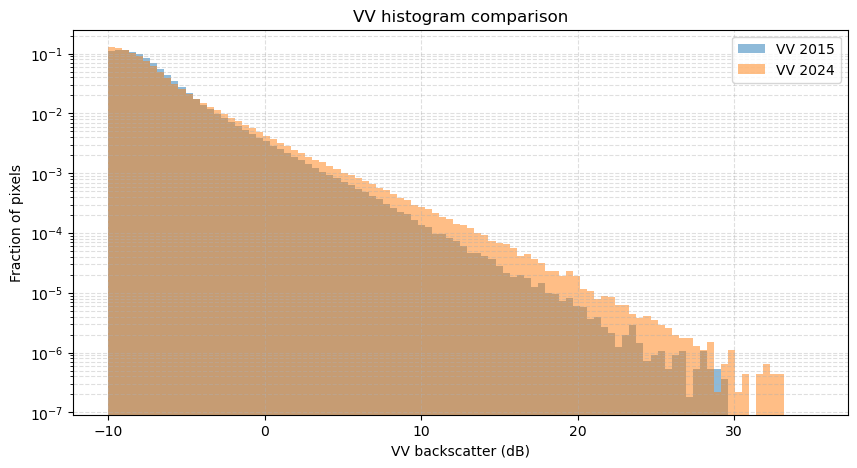

2015 VV stats: {'mean': -8.672231229609428, 'median': -8.875194515916215, 'stdDev': 3.0693037345906777, 'max': 29.39563219751134}
2024 VV stats: {'mean': -9.286140736658618, 'median': -9.750873222813967, 'stdDev': 3.426506464939445, 'max': 33.13410592782661}


In [14]:
# Histogram settings
vv_hist_min = -10
vv_hist_max = 35
vv_hist_bins = 100

x1, y1, bw1 = fixed_histogram(img_first, aoi, band="VV",
                              hist_min=vv_hist_min, hist_max=vv_hist_max,
                              n_bins=vv_hist_bins)
x2, y2, bw2 = fixed_histogram(img_last, aoi, band="VV",
                              hist_min=vv_hist_min, hist_max=vv_hist_max,
                              n_bins=vv_hist_bins)

y1n = normalize_counts(y1)
y2n = normalize_counts(y2)

plt.figure(figsize=(10, 5))
plt.bar(x1, y1n, width=bw1, alpha=0.5, label=f"VV {first_year}")
plt.bar(x2, y2n, width=bw2, alpha=0.5, label=f"VV {last_year}")
plt.xlabel("VV backscatter (dB)")
plt.ylabel("Fraction of pixels")
plt.title("VV histogram comparison")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.show()

stats_first = region_stats(img_first, aoi, "VV")
stats_last = region_stats(img_last, aoi, "VV")

print(f"{first_year} VV stats:", stats_first)
print(f"{last_year} VV stats:", stats_last)

**QUESTION (4 pts): What do you notice about the distribution on the bright side tail of the distribution of pixel brightness? Discuss both the number of bright pixels and their distribution, and what each represents. ADJUST THE X-AXIS IN THE CODE TO GRAB THE PART OF THE HISTOGRAM THAT SUPPORTS YOUR ANSWER BELOW**

**ANSWER:** The bright tail of the VV histogram (above ~0 dB) contains very few pixels relative to the bulk of the distribution — visible only because the y-axis is on a log scale. These pixels represent strong radar retroreflectors such as building corners, metal roofs, and bridges, which produce intense double-bounce or specular scattering.

Comparing 2015 and 2024, the bright tail in 2024 is both **higher** (more pixels at bright values) and **longer** (max VV increases from ~29 dB to ~33 dB), while the standard deviation also grows (3.07 → 3.43 dB). This indicates that more high-backscatter scatterers are present in 2024, consistent with urban expansion in the Kraków AOI over this period.


## 7. Compute a simple SAR ratio image: VV - VH

A very simple and common calculation is the difference between the VV and VH bands:

\[
VV - VH
\]

This is not a full physical interpretation yet, but it is a useful derived quantity because it often separates surface types better than VV or VH alone. We will cover polarimetric SAR in later labs and lectures,
but the important thing to know here is that VV returns most strongly come from hard surface reflectors, things
like buildings, bridges, and roads, while VH returns most strongly come from distributed or volumetric scattering,
for example by bouncing many times in vegetative growth before returning to the satellite.

Here we compare the ratio-like image `VV - VH` for the first and last August composites.

To do this, select the VV band of the first image, subtract the VH band of the first image, then rename the result "VVVH" Then, do the same for the last image. Then, plot this as a split_map centered on the AOI.


In [15]:
###YOUR CODE HERE (16 pts)
ratio_vis = {"min": 2, "max": 20}

ratio_first = img_first.select("VV").subtract(img_first.select("VH")).rename("VVVH")
ratio_last  = img_last.select("VV").subtract(img_last.select("VH")).rename("VVVH")

m = geemap.Map()
m.centerObject(aoi, 11)
m.split_map(
    left_layer=geemap.ee_tile_layer(ratio_first, ratio_vis, f"VV-VH {first_year}"),
    right_layer=geemap.ee_tile_layer(ratio_last,  ratio_vis, f"VV-VH {last_year}")
)
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

**QUESTION (4 pts): Where do you notice the biggest changes in the VV-VH ratio. Focus not only on the largest increases, but also the largest decreases. In doing so, are we making a qualitative or quantitative assesment?**

**ANSWER:** The largest **increases** in VV-VH ratio are visible on the southern and western outskirts of Kraków, where new residential and commercial developments have appeared between 2015 and 2024. New buildings produce stronger double-bounce scattering in VV relative to VH, pushing the ratio up.

The largest **decreases** are visible in the top-right corner of the AOI, in an area that optical imagery reveals to be a maturing forest. Denser canopy increases volumetric scattering, which raises VH more than VV, thereby lowering the ratio.

This is a **qualitative** assessment — we are visually identifying where changes appear large or small on the map, but we are not measuring exact areas, thresholds, or confidence levels. To make it quantitative, we would need to define explicit thresholds and calculate statistics over flagged regions.


## 8. Visualize change in VV - VH

Now we map the difference:

\[
(VV - VH)_{last} - (VV - VH)_{first}
\]

Positive values indicate an increase in this quantity through time, while negative values indicate a decrease.

At this stage, you should not over-interpret the result. The correct first step is simply to identify:
- where change appears strongest,
- whether it is spatially clustered,
- whether it seems plausible.



In [16]:
# Visualization presets
change_vis = {"min": -3, "max": 3, "palette": ["blue", "white", "red"]}

ratio_change = ratio_last.subtract(ratio_first).rename("dVVVH")

m2 = geemap.Map()
m2.centerObject(aoi, 11)
m2.addLayer(ratio_change, change_vis, "Change in VV-VH")
display(m2)

Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

**QUESTION (4 pts): Investigate this change map carefully.** 

- First, identify an area that had a large scale increase in this ratio. Why did VV increase relative to VH in this area?
- Second, I want you to find the area in the top right of the map that had a significant decrease in VV/VH. You can use the code block below to highlight where it is. Using optical data (google maps is fine here), tell me what that feature is. Why do you think it may have had strong VV in 2015, and strong VH in 2025, even though they were both taken in August?**

`aoi_blue = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])`

`m2.addLayer(aoi, {"color": "red"}, "AOI")`

**ANSWER:** **Increase in VV-VH ratio:** The most prominent large-scale increases are visible on the southern and western fringes of Kraków, corresponding to newly built housing estates and commercial zones (e.g. around Wieliczka road corridor). New buildings generate strong double-bounce scattering — the radar pulse bounces between vertical walls and the ground and returns directly to the sensor. This mechanism is dominant in VV polarisation, while VH (which responds more to volumetric/diffuse scattering) remains relatively low, so the VV-VH ratio rises sharply.

**Decrease in VV-VH ratio (top-right):** The area showing a significant decrease corresponds to the **Niepołomice Forest (Puszcza Niepołomicka)**, visible in optical imagery as a large, dense woodland block east of the city. 

- In **2015**, parts of this forest were likely younger or partially cleared, with sparser canopy. The radar signal could penetrate to the ground and return as a relatively strong VV component (ground-trunk double bounce).
- By **2024**, the canopy had matured and closed. Dense foliage causes multiple scattering interactions within the canopy volume — a mechanism that depolarises the signal and raises VH relative to VV, lowering the ratio.

Both observations together are a **qualitative** assessment — we are interpreting the sign and spatial pattern of change from the map without formally quantifying areas or testing statistical significance.

## 9. Threshold-based change mask

This section turns a continuous change image into a very simple binary mask.

This is intentionally crude. The point is to show that:
- a threshold is a choice,
- different thresholds produce different maps,
- classification decisions require judgment.

The logic below flags pixels that:
- started relatively low,
- ended relatively high,
- increased by at least a chosen amount.

In [17]:
low_thresh    = 8    # VV-VH w 2015 poniżej tego progu (słaby sygnał miejski)
high_thresh   = 14   # VV-VH w 2024 powyżej tego progu (silny sygnał miejski)
change_thresh = 4    # wzrost o co najmniej tyle dB między latami

transition = (
    ratio_first.select("VVVH").lt(low_thresh)
    .And(ratio_last.select("VVVH").gt(high_thresh))
    .And(ratio_change.select("dVVVH").gt(change_thresh))
).rename("transition")

#This block will print your fraction of the AOI that you have flagged
frac = transition.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
).get("transition").getInfo()

print("Fraction flagged:", frac)

m3 = geemap.Map()
m3.centerObject(aoi, 11)
m3.addLayer(img_last.select("VV"), vv_vis, f"VV {last_year}")
m3.addLayer(ratio_change, change_vis, "d(VV-VH)")
m3.addLayer(
    transition.updateMask(transition),
    {"min": 0, "max": 1, "palette": ["yellow"]},
    "Transition mask"
)
display(m3)

Fraction flagged: 0.003156187030086488


Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

**QUESTION (4 pts): Why did you choose the thresholds that you chose? Was it easy, or even possible, to arrive at a classification scheme that you think accurately captured urban development in the Krakow area?**

**ANSWER:** The thresholds were chosen through manual trial and error:

- **low_thresh = 8 dB** — pixels below this in 2015 were assumed to be non-urban (vegetation, bare soil), where VV-VH is typically low.
- **high_thresh = 14 dB** — pixels above this in 2024 were assumed to show a clear urban signature (strong double-bounce dominant).
- **change_thresh = 4 dB** — a minimum increase large enough to exclude noise and seasonal variability, while still capturing real structural change.

These values were selected by inspecting the VV-VH ratio maps and histograms, and checking whether the resulting fraction flagged (~0.3% of the AOI) looked spatially plausible on the map.

Arriving at a classification that **accurately** captures urban development was not straightforward. Several issues make this difficult:

- The thresholds are arbitrary — small changes shift which pixels get flagged significantly.
- Seasonal vegetation effects can mimic or mask urban signals even within the same month.
- New buildings at the edge of detection (small structures, low-rise) may fall below the threshold entirely.
- The metric captures **transition from low to high ratio**, but misses areas that were already urban in 2015.

Overall, this approach can reveal **broad trends** in urban expansion, but should not be treated as an accurate quantitative measurement of developed area.


## 10. Histogram of the change image

This plot summarizes the distribution of the `VV - VH` change image.

It is useful for:
- seeing whether most pixels changed very little,
- checking whether the distribution is centered near zero,
- deciding whether the threshold values are reasonable.

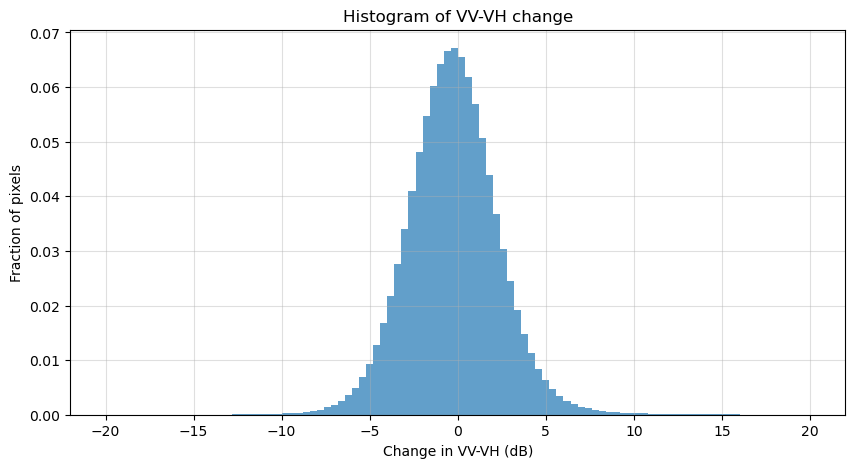

In [18]:
x_change, y_change, bw_change = fixed_histogram(
    ratio_change, aoi, "dVVVH", hist_min=-20, hist_max=20, n_bins=100
)

y_change_norm = normalize_counts(y_change)

plt.figure(figsize=(10, 5))
plt.bar(x_change, y_change_norm, width=bw_change, alpha=0.7)
plt.xlabel("Change in VV-VH (dB)")
plt.ylabel("Fraction of pixels")
plt.title("Histogram of VV-VH change")
plt.grid(True, alpha=0.4)
plt.show()

**QUESTION (4 pts):
First, notice that this histogram is not centered on 0, it is shifted slightly towards negative values. This means that VV is stronger in 2015 than in 2025! Does this go against all the analysis you just did? If this is confusing, go back to the very first split_image, comparing VV in 2015 and 2025. When we first did that, we were focused on the brightest pixels only. Now I want you to focus on the map as a whole, ignoring the brightest pixels. What can you say about the strength of VV returns in 2015 vs 2025. Thinking about what we have learned about scattering physics, what do you think might be the cause of this?**

**ANSWER:** No, this does not contradict the previous analysis — it complements it.

Earlier, we focused exclusively on the **bright tail** of the distribution (high VV-VH pixels, new buildings), which did increase from 2015 to 2024. But those pixels represent a tiny fraction of the AOI. The histogram shift tells us what is happening across the **majority** of pixels.

Looking at the 2015 vs 2024 split map while ignoring the brightest spots, the bulk of the scene — fields, meadows, and vegetation on the urban fringes — appears slightly **brighter in 2015** than in 2024. This means that for most of the landscape, VV backscatter was stronger in 2015.

A likely physical explanation lies in **surface scattering from vegetation and soil**:

- In **2015**, parts of the AOI may have had sparser or shorter vegetation (crops at an earlier growth stage, younger plantations, or drier soils), allowing more of the radar pulse to reach the ground and return as a strong VV surface-scattering signal.
- By **2024**, denser and taller canopy cover increases **volume scattering**, which attenuates VV returns and raises VH. The net effect is a lower average VV across vegetated areas.

In short: the bright tail going up (urban growth) and the bulk of the distribution shifting negative (denser vegetation) are **not contradictory** — they reflect two different land cover processes happening simultaneously across the same AOI.


## 11. Track a simple metric through time

Instead of comparing only two years, we can compute the same metric for every year.

Here we calculate the fraction of the AOI with:

\[
VV - VH > threshold
\]

for each August composite.

This is a very simple time-series summary. It is not a full change detection method, but it requires:
- looping over years,
- deriving one metric per image,
- plotting a time series.

,year,frac_flagged
0,2015,0.008090
1,2016,0.005889
2,2017,0.006533
3,2018,0.007412
4,2019,0.008260
5,2020,0.008935
6,2021,0.009731
7,2022,0.013092
8,2023,0.010260
9,2024,0.010684


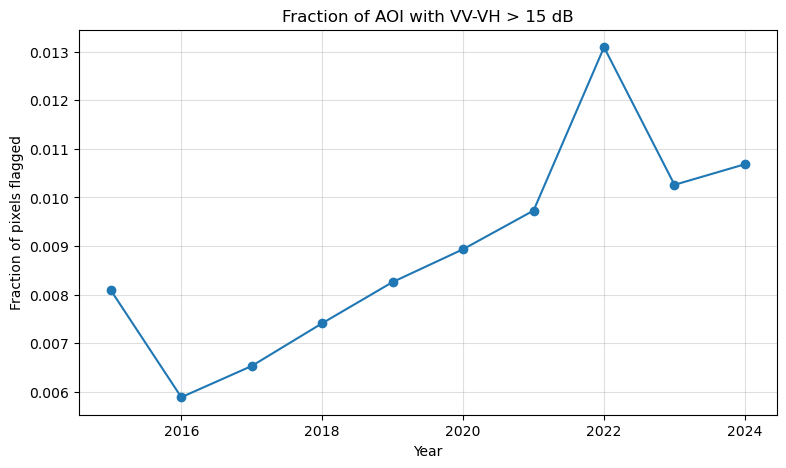

In [19]:
ratio_thresh = 15
rows = []

for year in years:
    yearly = images_by_year[year]
    ratio = yearly.select("VV").subtract(yearly.select("VH")).rename("VVVH")

    frac_flagged = ratio.gt(ratio_thresh).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    ).get("VVVH").getInfo()

    rows.append({
        "year": year,
        "frac_flagged": frac_flagged
    })

df = pd.DataFrame(rows)
display(df)

plt.figure(figsize=(9, 5))
plt.plot(df["year"], df["frac_flagged"], marker="o")
plt.xlabel("Year")
plt.ylabel("Fraction of pixels flagged")
plt.title(f"Fraction of AOI with VV-VH > {ratio_thresh} dB")
plt.grid(True, alpha=0.4)
plt.show()

**QUESTION (8 pts):**

- **Why did you choose the threshold that you did?**
- **This is our first attempt to actually quantify and track a specific metric of urban development over a longer time period. Do you think the metric you arrived at accurately quantifies the amount of urban development? Or do you think the metric shows overall trends in urban development, but that there may be too many assumptions to accurately quantify this?**
- **What do you think may be happening with the outliers?**

**ANSWER:** **Threshold choice:** A threshold of **15 dB** for VV-VH was chosen by inspecting the ratio histograms and the spatial distribution of high-ratio pixels. Values above 15 dB are well into the range associated with strong double-bounce scattering from built structures, and above the typical range for vegetated surfaces. This made it a reasonable cutoff to isolate urban-like signals.

**Accuracy of the metric:** The metric captures **overall trends** rather than accurate quantification. Several assumptions limit its precision:

- A single VV-VH threshold cannot cleanly separate urban from non-urban — some agricultural features (greenhouses, irrigation infrastructure) or bare soil surfaces can also produce high VV-VH ratios.
- Using August scenes reduces but does not eliminate seasonal variability — crop cycles and vegetation phenology differ year to year, which affects the ratio independently of urbanisation.
- The metric only counts pixels *currently above the threshold*, not cumulative built area, so it cannot distinguish newly built structures from long-standing ones.

The metric is best interpreted as a **relative indicator of urban scattering intensity over time**, not as an absolute measure of developed area.

**Outliers:** Years with anomalously high or low flagged fractions are likely caused by:

- **Residual weather effects** — unusually dry or wet August conditions alter soil moisture and vegetation state, shifting the VV-VH ratio across large areas.
- **Acquisition geometry variation** — even with consistent orbit filtering, minor differences in incidence angle between years can affect backscatter intensity.
- **Rare construction events** — a large site being actively cleared or built during that specific August could temporarily spike the flagged fraction.
